# **Data Preprocessing & Exploratory Data Analysis**

This notebook:
1. Loads all HumAID TSV files (set1 + set2, 17 events)
2. Maps 11 HumAID labels → 5 target classes
3. Preprocesses tweet text
4. Exploratory Data Analysis
5. Saves processed data for downstream notebooks

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

print("All imports successful!")

All imports successful!


## 1. Configuration

In [2]:
from pathlib import Path

#Path.cwd() gets the folder the notebook is in
#.parent goes up one level to your main project folder
BASE_DIR = Path.cwd().parent

#Now you can create paths to your data folders dynamically!
#pathlib lets you use the '/' operator to join paths cleanly
DATA_DIR = BASE_DIR / 'datasets'
PROCESSED_CSV = DATA_DIR / 'processed' / 'humaid_processed.csv'

print(f"Base Directory: {BASE_DIR}")
print(f"Data File Path: {PROCESSED_CSV}")

Base Directory: /home/rizwan/Documents/Projects/Multilingual-Classification-of-Urgent-Disaster-Response-Messages
Data File Path: /home/rizwan/Documents/Projects/Multilingual-Classification-of-Urgent-Disaster-Response-Messages/datasets/processed/humaid_processed.csv


In [3]:
SET1_DIR = os.path.join(BASE_DIR, "datasets", "raw", "HumAID_data_events_set1_47K", "events_set1")
SET2_DIR = os.path.join(BASE_DIR, "datasets", "raw", "HumAID_data_events_set2_29K", "events_set2")

SET1_EVENTS = [
    "canada_wildfires_2016", "cyclone_idai_2019", "ecuador_earthquake_2016",
    "hurricane_harvey_2017", "hurricane_irma_2017", "hurricane_maria_2017",
    "hurricane_matthew_2016", "italy_earthquake_aug_2016",
    "kaikoura_earthquake_2016", "puebla_mexico_earthquake_2017",
    "srilanka_floods_2017",
]

SET2_EVENTS = [
    "california_wildfires_2018", "hurricane_dorian_2019",
    "hurricane_florence_2018", "kerala_floods_2018",
    "midwestern_us_floods_2019", "pakistan_earthquake_2019",
]

In [4]:
CLASS_ORDER = [
    "Critical Rescue",
    "Resource Requests",
    "Situational Awareness",
    "Volunteering and Donations",
    "Irrelevant"
]

CLASS_COLORS = {
    "Critical Rescue": "#d32f2f",             # Red
    "Resource Requests": "#ff9800",           # Orange
    "Situational Awareness": "#1976d2",        # Blue
    "Volunteering and Donations": "#4caf50",  # Green
    "Irrelevant": "#9e9e9e"                   # Grey
}

In [5]:
PROCESSED_CSV = os.path.join(BASE_DIR, "datasets", "processed", "humaid_processed.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

In [6]:
# Plot subfolders per notebook
PLOTS_DIR = {
    "eda":      os.path.join(RESULTS_DIR, "plots", "eda"),
    "svm":      os.path.join(RESULTS_DIR, "plots", "svm"),
    "nb":       os.path.join(RESULTS_DIR, "plots", "naive_bayes"),
    "lr":       os.path.join(RESULTS_DIR, "plots", "logistic_regression"),
}

In [7]:
# Create all directories
os.makedirs(os.path.dirname(PROCESSED_CSV), exist_ok=True)
for folder in PLOTS_DIR.values():
    os.makedirs(folder, exist_ok=True)

In [8]:
print("Directory structure created:")
print(f"  data/processed/")
for key, path in PLOTS_DIR.items():
    print(f"  results/plots/{os.path.basename(path)}/")

Directory structure created:
  data/processed/
  results/plots/eda/
  results/plots/svm/
  results/plots/naive_bayes/
  results/plots/logistic_regression/


## 2. Load HumAID Data

Loading all train/dev/test TSV files across both event sets.

In [9]:
all_dfs = []

for event_set, (events, base_path) in enumerate(
    [(SET1_EVENTS, SET1_DIR), (SET2_EVENTS, SET2_DIR)], start=1
):
    for event in events:
        event_dir = os.path.join(base_path, event)
        if not os.path.isdir(event_dir):
            print(f"  [WARNING] Not found: {event_dir}")
            continue

        for split_name in ["train", "dev", "test"]:
            filepath = os.path.join(event_dir, f"{event}_{split_name}.tsv")
            if not os.path.isfile(filepath):
                continue

            temp_df = pd.read_csv(filepath, sep="\t", quoting=3)
            temp_df["event"] = event
            temp_df["split"] = split_name
            temp_df["event_set"] = f"set{event_set}"
            all_dfs.append(temp_df)
            print(f"  {event}_{split_name}.tsv: {len(temp_df)} rows")

  canada_wildfires_2016_train.tsv: 1569 rows
  canada_wildfires_2016_dev.tsv: 228 rows
  canada_wildfires_2016_test.tsv: 445 rows
  cyclone_idai_2019_train.tsv: 2753 rows
  cyclone_idai_2019_dev.tsv: 401 rows
  cyclone_idai_2019_test.tsv: 779 rows
  ecuador_earthquake_2016_train.tsv: 1094 rows
  ecuador_earthquake_2016_dev.tsv: 159 rows
  ecuador_earthquake_2016_test.tsv: 310 rows
  hurricane_harvey_2017_train.tsv: 6378 rows
  hurricane_harvey_2017_dev.tsv: 929 rows
  hurricane_harvey_2017_test.tsv: 1805 rows
  hurricane_irma_2017_train.tsv: 6579 rows
  hurricane_irma_2017_dev.tsv: 958 rows
  hurricane_irma_2017_test.tsv: 1862 rows
  hurricane_maria_2017_train.tsv: 5094 rows
  hurricane_maria_2017_dev.tsv: 742 rows
  hurricane_maria_2017_test.tsv: 1442 rows
  hurricane_matthew_2016_train.tsv: 1157 rows
  hurricane_matthew_2016_dev.tsv: 168 rows
  hurricane_matthew_2016_test.tsv: 329 rows
  italy_earthquake_aug_2016_train.tsv: 840 rows
  italy_earthquake_aug_2016_dev.tsv: 122 rows
  ita

In [10]:
df = pd.concat(all_dfs, ignore_index=True)

print(f"\n{'='*50}")
print(f"Total rows: {len(df)}")
print(f"  Set1: {len(df[df['event_set']=='set1'])}")
print(f"  Set2: {len(df[df['event_set']=='set2'])}")
print(f"  Events: {df['event'].nunique()}")
print(f"  Splits: {df['split'].value_counts().to_dict()}")
print(f"{'='*50}")


Total rows: 74227
  Set1: 41152
  Set2: 33075
  Events: 17
  Splits: {'train': 51952, 'test': 14711, 'dev': 7564}


In [11]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nOriginal HumAID label distribution:")
print(df["class_label"].value_counts())
df.head()

Shape: (74227, 6)
Columns: ['tweet_id', 'tweet_text', 'class_label', 'event', 'split', 'event_set']

Null values:
tweet_id       0
tweet_text     0
class_label    0
event          0
split          0
event_set      0
dtype: int64

Original HumAID label distribution:
class_label
rescue_volunteering_or_donation_effort    20849
other_relevant_information                11848
sympathy_and_support                       8499
infrastructure_and_utility_damage          8046
injured_or_dead_people                     6752
not_humanitarian                           6145
caution_and_advice                         5298
displaced_people_and_evacuations           3999
requests_or_urgent_needs                   2593
missing_or_found_people                     198
Name: count, dtype: int64


,tweet_id,tweet_text,class_label,event,split,event_set
0,735891446960623616,RT @DonBradshawNTV: How @MarshallAmpsUK came t...,other_relevant_information,canada_wildfires_2016,train,set1
1,731202020296818688,Red Cross distributes $30M to Fort McMurray wi...,displaced_people_and_evacuations,canada_wildfires_2016,train,set1
2,733665357236342784,Interesting insights on the shifting communica...,other_relevant_information,canada_wildfires_2016,train,set1
3,731963038429929472,RT @globeandmail: Oil sands producers helping ...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1
4,728674838034944001,Ottawa to match Red Cross donations for Fort M...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1


## 3. Map HumAID Labels → 5 Target Classes

| HumAID Label | → Target Class |
|---|---|
| `displaced_people_and_evacuations`, `injured_or_dead_people`, `missing_or_found_people` | **Critical Rescue** |
| `requests_or_urgent_needs` | **Resource Requests** |
| `rescue_volunteering_or_donation_effort` | **Volunteering and Donations** |
| `caution_and_advice`, `infrastructure_and_utility_damage`, `other_relevant_information` | **Situational Awareness** |
| `sympathy_and_support`, `not_humanitarian`, `dont_know_cant_judge` | **Irrelevant** |

In [12]:
LABEL_MAP = {
    # 1. Critical Rescue
    "displaced_people_and_evacuations": "Critical Rescue",
    "injured_or_dead_people": "Critical Rescue",
    "missing_or_found_people": "Critical Rescue",
    
    # 2. Resource Requests
    "requests_or_urgent_needs": "Resource Requests",
    
    # 3. Volunteering and Donations
    "rescue_volunteering_or_donation_effort": "Volunteering and Donations",
    
    # 4. Situational Awareness
    "caution_and_advice": "Situational Awareness",
    "infrastructure_and_utility_damage": "Situational Awareness",
    "other_relevant_information": "Situational Awareness",

    # 5. Irrelevant
    "sympathy_and_support": "Situational Awareness",
    "not_humanitarian": "Irrelevant",
    "dont_know_cant_judge": "Irrelevant"
}

In [13]:
df["target_label"] = df["class_label"].map(LABEL_MAP)

# Check for any unmapped labels
unmapped = df["target_label"].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows have unmapped labels:")
    print(df[df["target_label"].isna()]["class_label"].value_counts())
else:
    print("All labels mapped successfully!")

All labels mapped successfully!


In [14]:
# Mapping summary
print("\nLabel mapping summary:")
print("-" * 60)
mapping_check = df.groupby(["class_label", "target_label"]).size().reset_index(name="count")
print(mapping_check.to_string(index=False))


Label mapping summary:
------------------------------------------------------------
                           class_label               target_label  count
                    caution_and_advice      Situational Awareness   5298
      displaced_people_and_evacuations            Critical Rescue   3999
     infrastructure_and_utility_damage      Situational Awareness   8046
                injured_or_dead_people            Critical Rescue   6752
               missing_or_found_people            Critical Rescue    198
                      not_humanitarian                 Irrelevant   6145
            other_relevant_information      Situational Awareness  11848
              requests_or_urgent_needs          Resource Requests   2593
rescue_volunteering_or_donation_effort Volunteering and Donations  20849
                  sympathy_and_support      Situational Awareness   8499


In [15]:
print("Target class distribution:")
print("=" * 60)
counts = df["target_label"].value_counts().reindex(CLASS_ORDER)
for cls in CLASS_ORDER:
    c = counts[cls]
    print(f"  {cls:30s}: {c:6,}  ({c/len(df)*100:.1f}%)")

Target class distribution:
  Critical Rescue               : 10,949  (14.8%)
  Resource Requests             :  2,593  (3.5%)
  Situational Awareness         : 33,691  (45.4%)
  Volunteering and Donations    : 20,849  (28.1%)
  Irrelevant                    :  6,145  (8.3%)


In [33]:
print(f"\nSample tweets per class:")
for label in CLASS_ORDER:
    subset = df[df["target_label"] == label]
    print(f"\n--- {label} ({len(subset):,} samples) ---")
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f"  > {row['tweet_text'][:140]}")


Sample tweets per class:

--- Critical Rescue (10,949 samples) ---
  > RT @RT_com: #ItalyEarthquake UPDATE: Death toll rises to 73 - Civil Protection Department official
  > Steve Perez died trying to save victims of #HurricaneHarvey. Meanwhile, @realDonaldTrump arrived with this message:

--- Resource Requests (2,593 samples) ---
  > @PaulMcCartney i ask for your help here in Ecuador for the earth quake that we have yesterday @brianrayguitar @rustyanderson1 thank you!!!
  > Dear friends,my friends family and few others ( 50 people ) are stuck in a high school in Chendamangalam of North Paravur,Ernakulam district

--- Situational Awareness (33,691 samples) ---
  > #Kerala, After The Flood: If it was mismanagement in controlling the water from #Idukki dam that sent the #Periyar into #Kochi city, in #Pat
  > At 12:00 PM EDT, 1 ENE Whispering Pines [Moore Co, NC] 911 CALL CENTER reports FLASH FLOOD. SOUTH LAKESHORE DRIVE AT NIAGARA CARTHAGE ROAD W

--- Volunteering and Donations (20,849 

## 4. Text Preprocessing

Cleaning steps:
- Remove URLs
- Remove RT (retweet) prefix
- Remove @mentions
- Normalize hashtags (`#KeralaFloods` → `KeralaFloods`)
- Decode HTML entities (`&amp;` → `and`)
- Remove special characters (keep basic punctuation)
- Normalize whitespace
- Lowercase

Hashtag words are kept because they carry semantic meaning in disaster tweets.

In [34]:
def preprocess_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"^RT\s+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"&amp;", "and", text)
    text = re.sub(r"&lt;", "<", text)
    text = re.sub(r"&gt;", ">", text)
    text = re.sub(r"[^\w\s.,!?'-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df["clean_text"] = df["tweet_text"].apply(preprocess_text)

In [35]:
# Drop empty rows after cleaning
empty_mask = df["clean_text"].str.strip() == ""
print(f"Dropped {empty_mask.sum()} empty rows after cleaning")
df = df[~empty_mask].reset_index(drop=True)

# Before / after examples
print(f"\nPreprocessed {len(df)} rows. Examples:")
print("-" * 70)
for _, row in df.sample(1, random_state=42).iterrows():
    print(f"  ORIG:  {row['tweet_text'][:100]}")
    print(f"  CLEAN: {row['clean_text'][:100]}")
    print()

Dropped 0 empty rows after cleaning

Preprocessed 74227 rows. Examples:
----------------------------------------------------------------------
  ORIG:  Media to emphasize Use Ananthapadmanaba temple treasure to Kerala flood relief work
  CLEAN: media to emphasize use ananthapadmanaba temple treasure to kerala flood relief work



## 5. Exploratory Data Analysis

### 5.1 Target Class Distribution

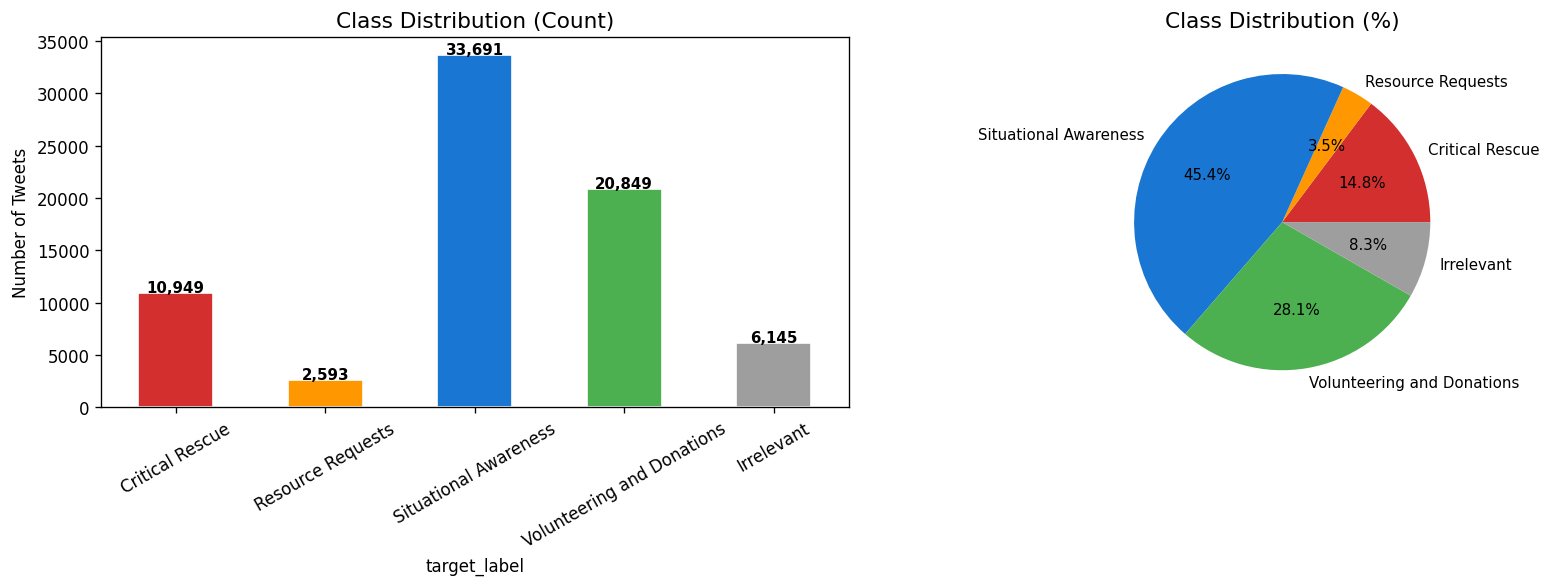


Exact counts and percentages:
  Critical Rescue               : 10,949  (14.8%)
  Resource Requests             :  2,593  (3.5%)
  Situational Awareness         : 33,691  (45.4%)
  Volunteering and Donations    : 20,849  (28.1%)
  Irrelevant                    :  6,145  (8.3%)


In [36]:
counts = df["target_label"].value_counts().reindex(CLASS_ORDER)
bar_colors = [CLASS_COLORS[c] for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts.plot(kind="bar", ax=axes[0], color=bar_colors, edgecolor="white")
axes[0].set_title("Class Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Number of Tweets")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", colors=bar_colors,
            textprops={"fontsize": 9})
axes[1].set_ylabel("")
axes[1].set_title("Class Distribution (%)", fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["eda"], "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nExact counts and percentages:")
for cls in CLASS_ORDER:
    c = counts[cls]
    print(f"  {cls:30s}: {c:6,}  ({c/len(df)*100:.1f}%)")

### 5.2 Class Imbalance Analysis

In [37]:
majority = counts.max()
print("Imbalance ratios (majority class / each class):")
for cls in CLASS_ORDER:
    ratio = majority / counts[cls]
    print(f"  {cls:30s}: {ratio:.1f}x")

print(f"\nMost underrepresented: {counts.idxmin()} ({counts.min():,})")
print(f"Most overrepresented:  {counts.idxmax()} ({counts.max():,})")
print(f"\n→ Will use class_weight='balanced' in all classifiers to handle this.")

Imbalance ratios (majority class / each class):
  Critical Rescue               : 3.1x
  Resource Requests             : 13.0x
  Situational Awareness         : 1.0x
  Volunteering and Donations    : 1.6x
  Irrelevant                    : 5.5x

Most underrepresented: Resource Requests (2,593)
Most overrepresented:  Situational Awareness (33,691)

→ Will use class_weight='balanced' in all classifiers to handle this.


### 5.3 Text Length Analysis

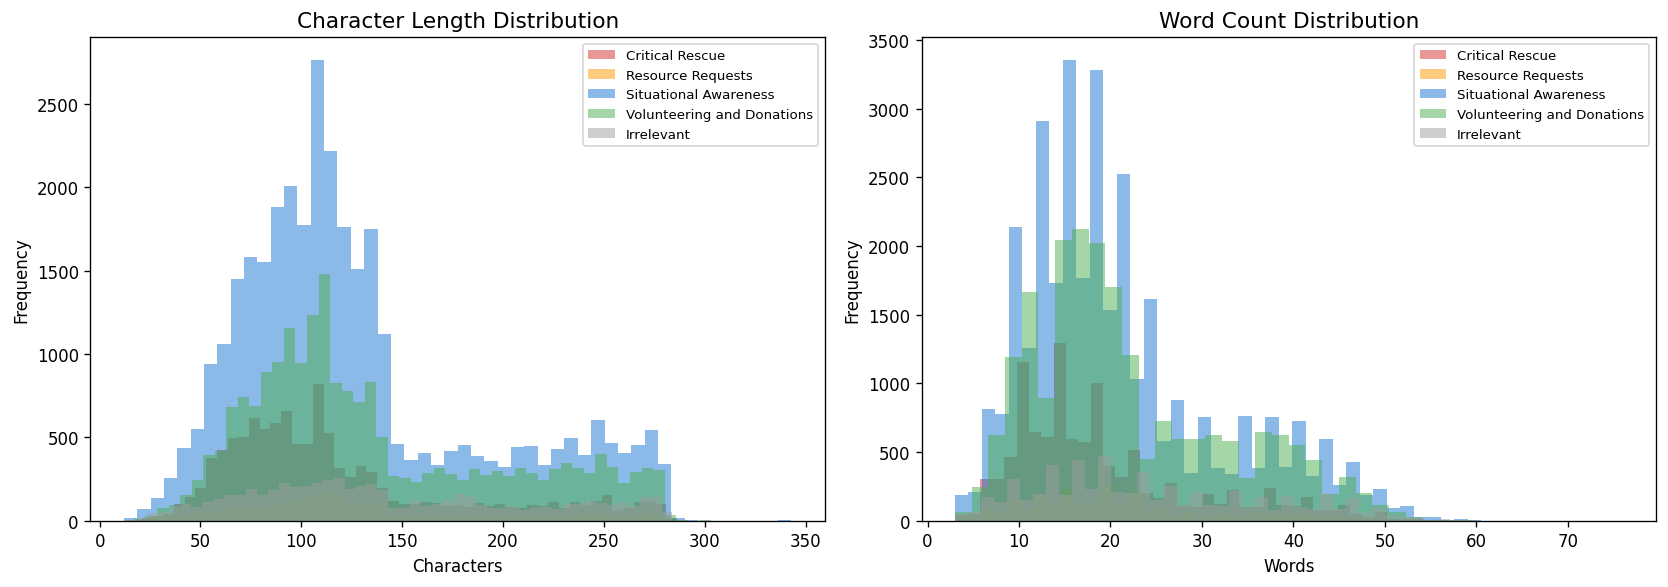

In [38]:
df["text_length"] = df["clean_text"].astype(str).apply(len)
df["word_count"] = df["clean_text"].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in CLASS_ORDER:
    subset = df[df["target_label"] == label]
    axes[0].hist(subset["text_length"], bins=50, alpha=0.5,
                 label=label, color=CLASS_COLORS[label])
axes[0].set_title("Character Length Distribution", fontsize=13)
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=8)

for label in CLASS_ORDER:
    subset = df[df["target_label"] == label]
    axes[1].hist(subset["word_count"], bins=40, alpha=0.5,
                 label=label, color=CLASS_COLORS[label])
axes[1].set_title("Word Count Distribution", fontsize=13)
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["eda"], "text_lengths.png"), dpi=150, bbox_inches="tight")
plt.show()

In [39]:
print("Text length statistics per class (word count):")
print("-" * 70)
stats = df.groupby("target_label")["word_count"].describe()[["mean", "std", "min", "50%", "max"]]
stats = stats.reindex(CLASS_ORDER)
stats.columns = ["Mean", "Std", "Min", "Median", "Max"]
print(stats.round(1))

Text length statistics per class (word count):
----------------------------------------------------------------------
                            Mean   Std  Min  Median   Max
target_label                                             
Critical Rescue             19.4  10.2  3.0    17.0  57.0
Resource Requests           21.2  10.6  3.0    19.0  61.0
Situational Awareness       21.2  10.7  3.0    18.0  62.0
Volunteering and Donations  22.0  10.7  3.0    19.0  76.0
Irrelevant                  24.4  12.3  3.0    22.0  60.0


### 5.4 Class Distribution per Event

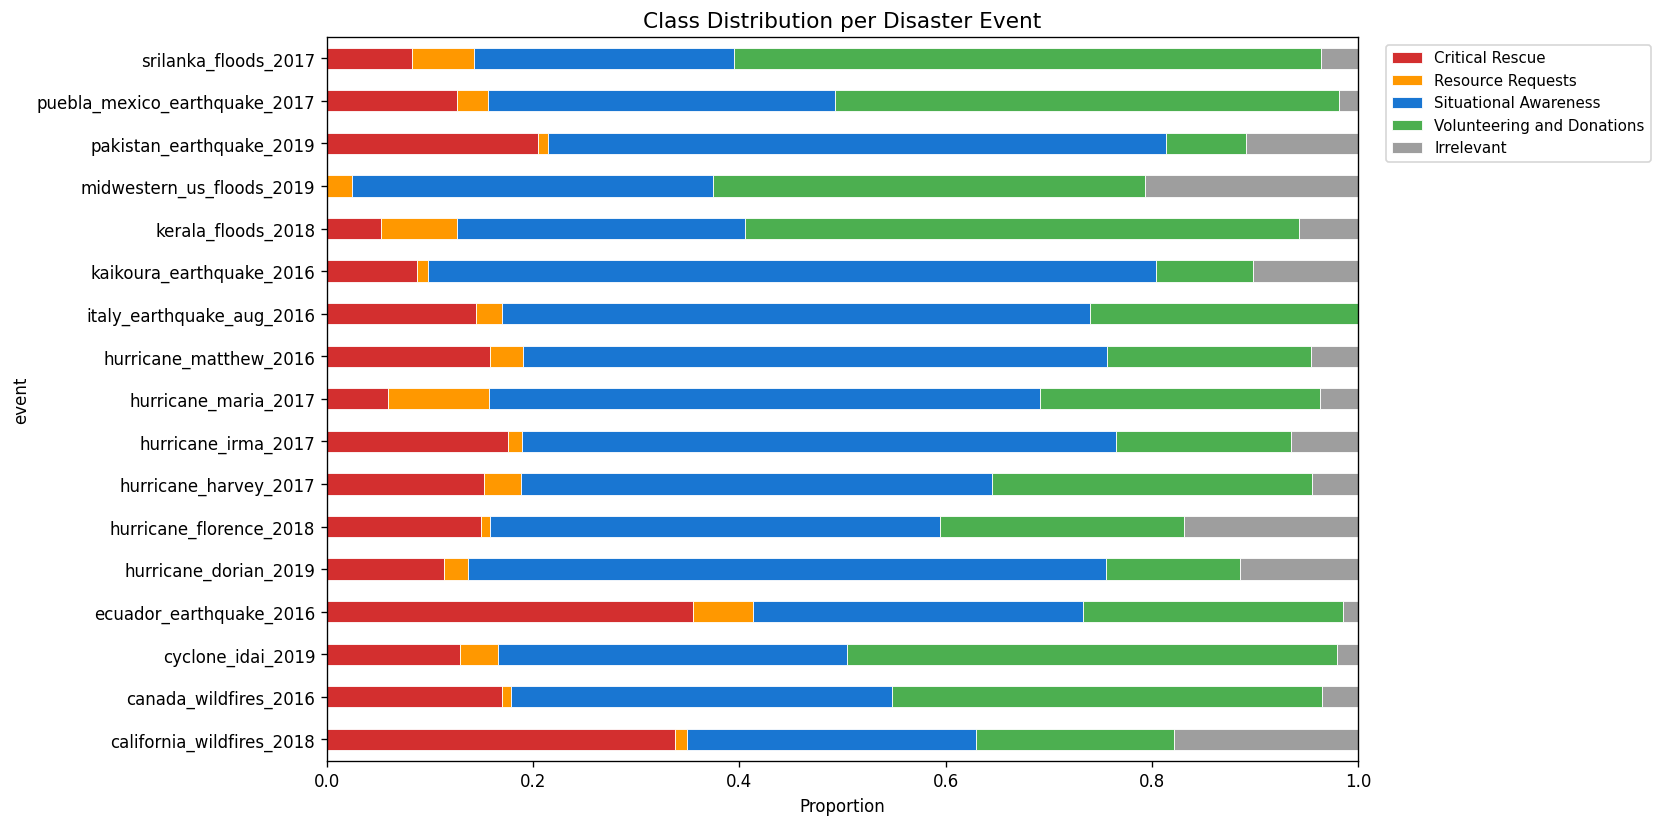

Samples per event:
event
hurricane_irma_2017              9399
hurricane_harvey_2017            9112
kerala_floods_2018               7984
hurricane_dorian_2019            7613
california_wildfires_2018        7376
hurricane_maria_2017             7278
hurricane_florence_2018          6264
cyclone_idai_2019                3933
canada_wildfires_2016            2242
kaikoura_earthquake_2016         2195
puebla_mexico_earthquake_2017    2015
pakistan_earthquake_2019         1958
midwestern_us_floods_2019        1880
hurricane_matthew_2016           1654
ecuador_earthquake_2016          1563
italy_earthquake_aug_2016        1201
srilanka_floods_2017              560


In [40]:
event_class = pd.crosstab(df["event"], df["target_label"]).reindex(columns=CLASS_ORDER)
event_class_pct = event_class.div(event_class.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
event_class_pct.plot(
    kind="barh", stacked=True, ax=ax,
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    edgecolor="white", linewidth=0.5,
)
ax.set_title("Class Distribution per Disaster Event", fontsize=13)
ax.set_xlabel("Proportion")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["eda"], "per_event_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Samples per event:")
print(df["event"].value_counts().to_string())

### 5.5 Top Words per Class

In [41]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))
# Add social media specific stopwords
STOPWORDS.update(["rt", "amp", "via", "like", "got", "get", "one", "two", "new",
                  "would", "could", "also", "us", "go", "say", "https", "co"])

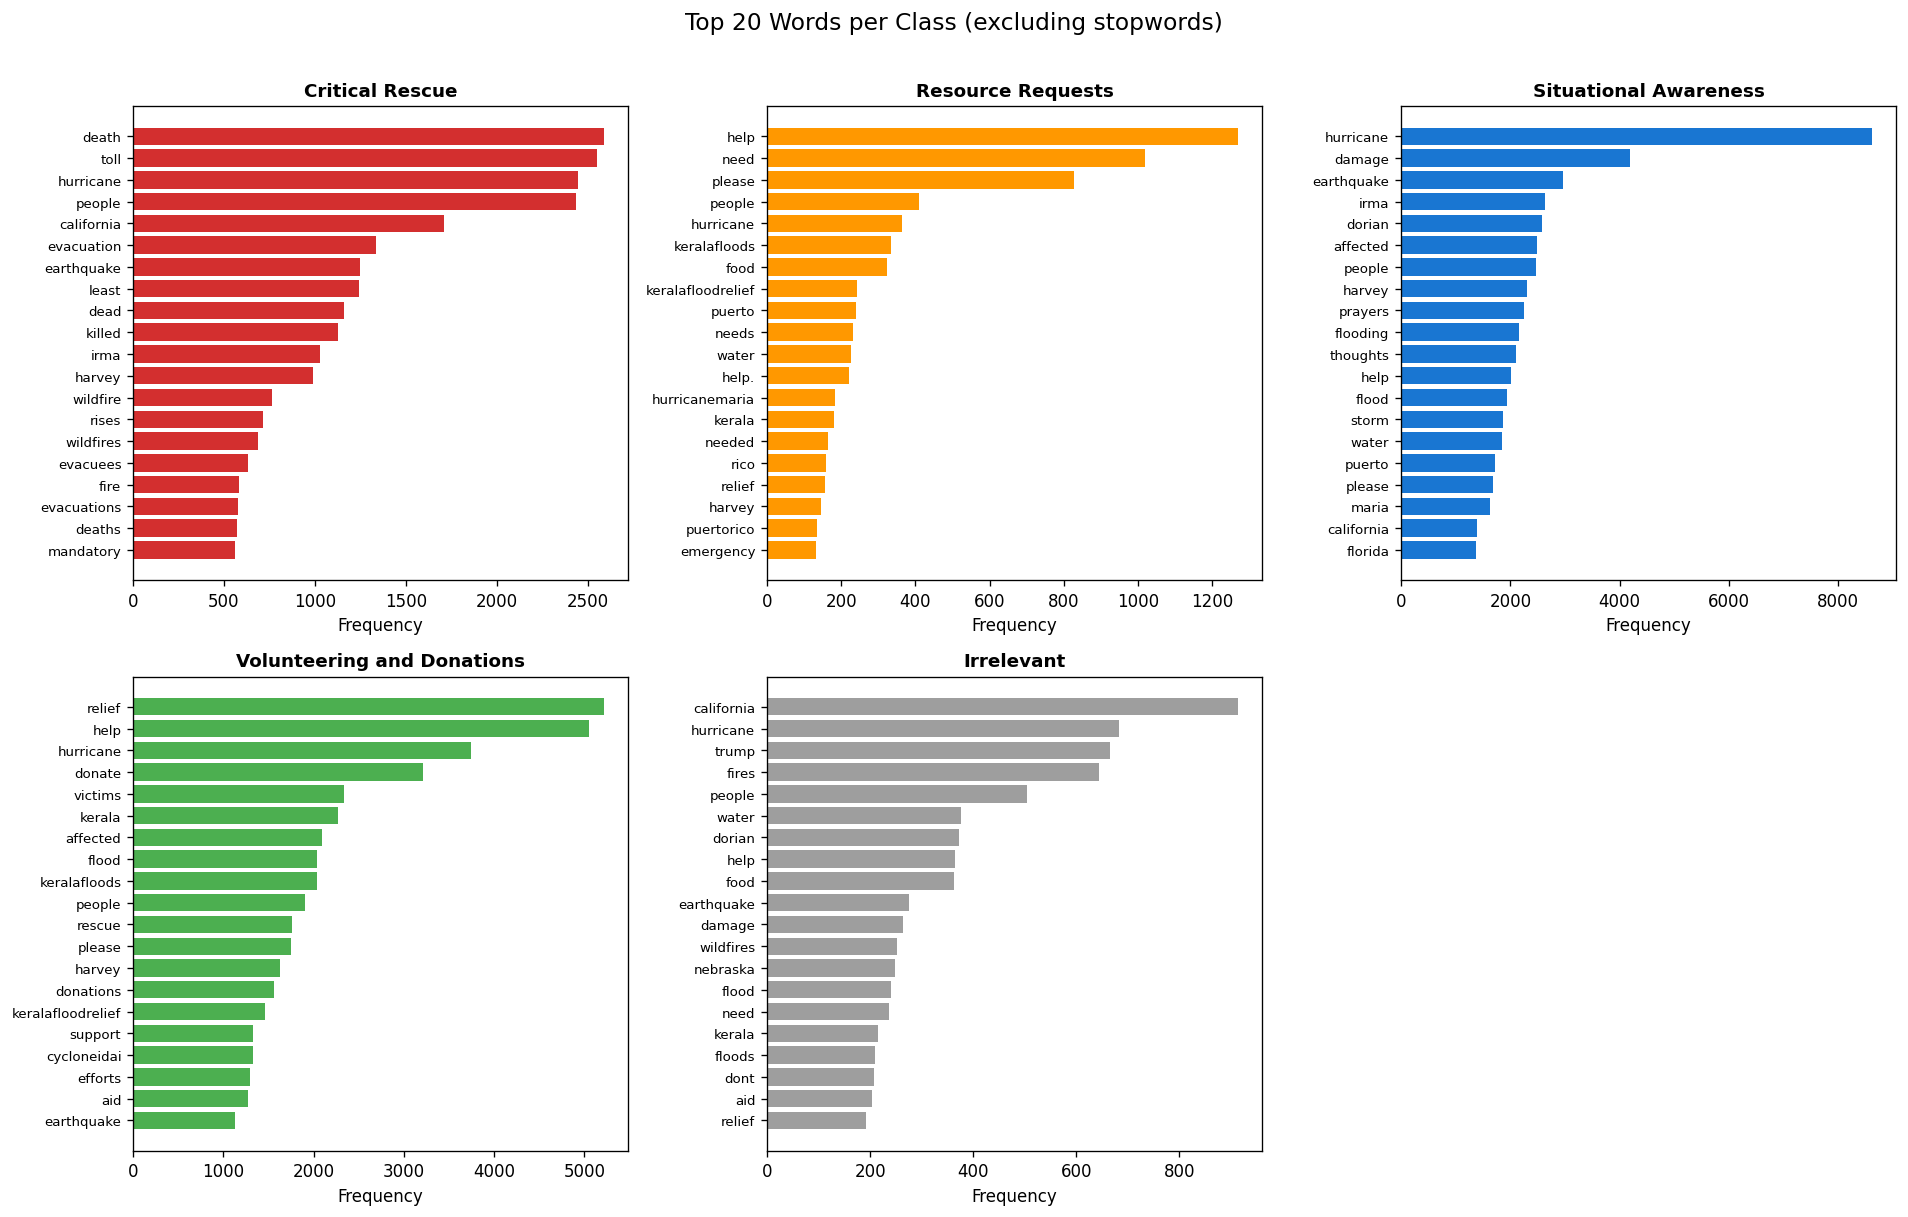

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, label in enumerate(CLASS_ORDER):
    subset = df[df["target_label"] == label]["clean_text"]
    all_words = " ".join(subset).split()
    filtered = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
    top_20 = Counter(filtered).most_common(20)

    words, freq = zip(*top_20) if top_20 else ([], [])
    axes[idx].barh(range(len(words)), freq, color=CLASS_COLORS[label])
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words, fontsize=8)
    axes[idx].invert_yaxis()
    axes[idx].set_title(label, fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Frequency")

axes[5].set_visible(False)

plt.suptitle("Top 20 Words per Class (excluding stopwords)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["eda"], "top_words_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.6 Sample Tweets per Class

In [43]:
for label in CLASS_ORDER:
    subset = df[df["target_label"] == label]
    print(f"\n{'='*70}")
    print(f"  {label}  ({len(subset):,} samples)")
    print(f"{'='*70}")
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f"  [{row['event']}]")
        print(f"  > {row['tweet_text'][:150]}")
        print()


  Critical Rescue  (10,949 samples)
  [italy_earthquake_aug_2016]
  > RT @RT_com: #ItalyEarthquake UPDATE: Death toll rises to 73 - Civil Protection Department official

  [hurricane_harvey_2017]
  > Steve Perez died trying to save victims of #HurricaneHarvey. Meanwhile, @realDonaldTrump arrived with this message:


  Resource Requests  (2,593 samples)
  [ecuador_earthquake_2016]
  > @PaulMcCartney i ask for your help here in Ecuador for the earth quake that we have yesterday @brianrayguitar @rustyanderson1 thank you!!!

  [kerala_floods_2018]
  > Dear friends,my friends family and few others ( 50 people ) are stuck in a high school in Chendamangalam of North Paravur,Ernakulam district,Kerala. T


  Situational Awareness  (33,691 samples)
  [kerala_floods_2018]
  > #Kerala, After The Flood: If it was mismanagement in controlling the water from #Idukki dam that sent the #Periyar into #Kochi city, in #Pathanamthitt

  [hurricane_florence_2018]
  > At 12:00 PM EDT, 1 ENE Whispering Pines

### 5.7 Train vs Test Class Balance

                            Train Count  Train %  Test Count  Test %
target_label                                                        
Critical Rescue                    7663     14.8        2167    14.7
Resource Requests                  1815      3.5         516     3.5
Situational Awareness             23582     45.4        6679    45.4
Volunteering and Donations        14591     28.1        4133    28.1
Irrelevant                         4301      8.3        1216     8.3


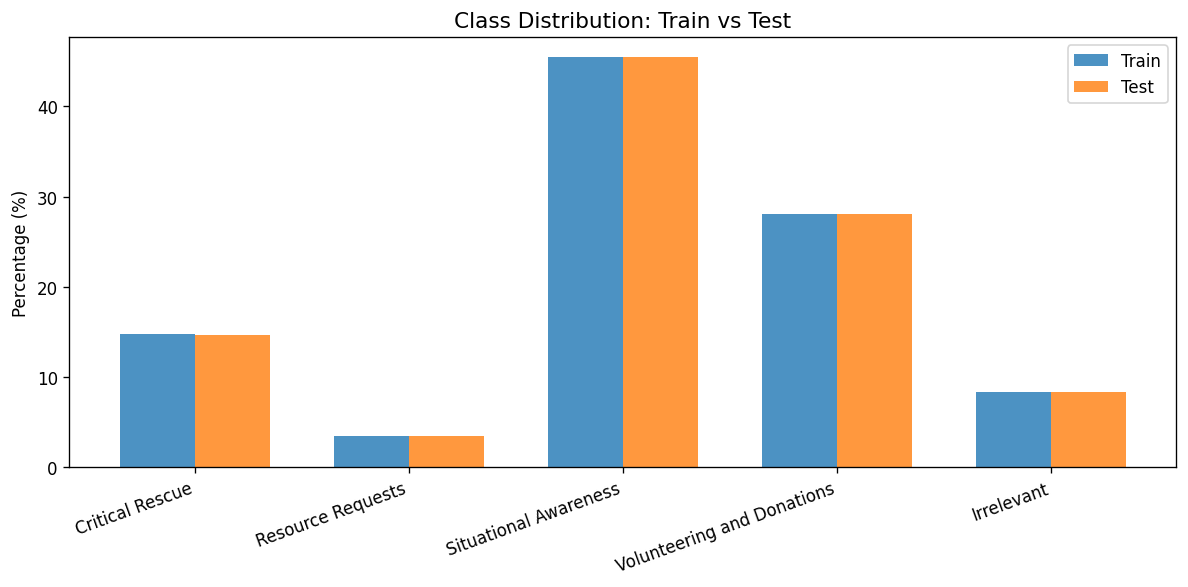

In [44]:
train_counts = df[df["split"]=="train"]["target_label"].value_counts().reindex(CLASS_ORDER)
test_counts  = df[df["split"]=="test"]["target_label"].value_counts().reindex(CLASS_ORDER)

train_pct = (train_counts / train_counts.sum() * 100).round(1)
test_pct  = (test_counts / test_counts.sum() * 100).round(1)

balance_df = pd.DataFrame({
    "Train Count": train_counts,
    "Train %": train_pct,
    "Test Count": test_counts,
    "Test %": test_pct,
})
print(balance_df)

x = np.arange(len(CLASS_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, train_pct, width, label="Train", alpha=0.8)
ax.bar(x + width/2, test_pct, width, label="Test", alpha=0.8)
ax.set_ylabel("Percentage (%)")
ax.set_title("Class Distribution: Train vs Test", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["eda"], "train_test_balance.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Save Processed Data

This CSV will be loaded by all downstream notebooks (baselines, XLM-RoBERTa, etc.)

In [45]:
df.to_csv(PROCESSED_CSV, index=False)

print(f"Saved {len(df)} rows to {PROCESSED_CSV}")
print(f"Columns: {list(df.columns)}")
print(f"File size: {os.path.getsize(PROCESSED_CSV) / (1024*1024):.1f} MB")

print(f"\nSplit breakdown:")
print(f"  Train: {len(df[df['split']=='train'])}")
print(f"  Dev:   {len(df[df['split']=='dev'])}")
print(f"  Test:  {len(df[df['split']=='test'])}")

Saved 74227 rows to /home/rizwan/Documents/Projects/Multilingual-Classification-of-Urgent-Disaster-Response-Messages/datasets/processed/humaid_processed.csv
Columns: ['tweet_id', 'tweet_text', 'class_label', 'event', 'split', 'event_set', 'target_label', 'clean_text', 'text_length', 'word_count']
File size: 27.3 MB

Split breakdown:
  Train: 51952
  Dev:   7564
  Test:  14711
